In [3]:
# house pricing dataset
from fairlearn.datasets import fetch_boston

In [4]:
X, y = fetch_boston(return_X_y=True, as_frame=True)
X.shape, y.shape

c:\Users\Admin\miniconda3\envs\fcc\Lib\site-packages\fairlearn\datasets\_fetch_boston.py:133: DataFairnessWarning: You are about to use a dataset with known fairness issues.
  warnings.warn(DataFairnessWarning(msg))


((506, 13), (506,))

In [5]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

The following describes the dataset columns:

* CRIM - per capita crime rate by town
* ZN - proportion of residential land zoned for lots over 25,000 sq.ft.
* INDUS - proportion of non-retail business acres per town.
* CHAS - Charles River dummy variable (1 if tract bounds river; 0 otherwise)
* NOX - nitric oxides concentration (parts per 10 million)
* RM - average number of rooms per dwelling
* AGE - proportion of owner-occupied units built prior to 1940
* DIS - weighted distances to five Boston employment centres
* RAD - index of accessibility to radial highways
* TAX - full-value property-tax rate per $10,000
* PTRATIO - pupil-teacher ratio by town
* B - 1000(Bk - 0.63)^2 where Bk is the proportion of blacks by town
* LSTAT - % lower status of the population
* MEDV - Median value of owner-occupied homes in $1000's

In [6]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 13 columns):
 #   Column   Non-Null Count  Dtype   
---  ------   --------------  -----   
 0   CRIM     506 non-null    float64 
 1   ZN       506 non-null    float64 
 2   INDUS    506 non-null    float64 
 3   CHAS     506 non-null    category
 4   NOX      506 non-null    float64 
 5   RM       506 non-null    float64 
 6   AGE      506 non-null    float64 
 7   DIS      506 non-null    float64 
 8   RAD      506 non-null    category
 9   TAX      506 non-null    float64 
 10  PTRATIO  506 non-null    float64 
 11  B        506 non-null    float64 
 12  LSTAT    506 non-null    float64 
dtypes: category(2), float64(11)
memory usage: 45.1 KB


In [7]:
X["CHAS"] = X["CHAS"].astype(float)
X["RAD"] = X["RAD"].astype(float)

In [8]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 13 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     506 non-null    float64
 1   ZN       506 non-null    float64
 2   INDUS    506 non-null    float64
 3   CHAS     506 non-null    float64
 4   NOX      506 non-null    float64
 5   RM       506 non-null    float64
 6   AGE      506 non-null    float64
 7   DIS      506 non-null    float64
 8   RAD      506 non-null    float64
 9   TAX      506 non-null    float64
 10  PTRATIO  506 non-null    float64
 11  B        506 non-null    float64
 12  LSTAT    506 non-null    float64
dtypes: float64(13)
memory usage: 51.5 KB


In [9]:
X.describe()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,3.613524,11.363636,11.136779,0.069170,0.554695,6.284634,68.574901,3.795043,9.549407,408.237154,18.455534,356.674032,12.653063
std,8.601545,23.322453,6.860353,0.253994,0.115878,0.702617,28.148861,2.105710,8.707259,168.537116,2.164946,91.294864,7.141062
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,0.320000,1.730000
25%,0.082045,0.000000,5.190000,0.000000,0.449000,5.885500,45.025000,2.100175,4.000000,279.000000,17.400000,375.377500,6.950000
50%,0.256510,0.000000,9.690000,0.000000,0.538000,6.208500,77.500000,3.207450,5.000000,330.000000,19.050000,391.440000,11.360000
75%,3.677083,12.500000,18.100000,0.000000,0.624000,6.623500,94.075000,5.188425,24.000000,666.000000,20.200000,396.225000,16.955000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,396.900000,37.970000


In [10]:
df = pd.concat([X, y], axis=1)
df.head(3)

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1.0,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2.0,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2.0,242.0,17.8,392.83,4.03,34.7


In [11]:
corr_matrix = df.select_dtypes(include="number").corr()
corr_matrix["MEDV"].sort_values(ascending=False)

MEDV       1.000000
RM         0.695360
ZN         0.360445
B          0.333461
DIS        0.249929
CHAS       0.175260
AGE       -0.376955
RAD       -0.381626
CRIM      -0.388305
NOX       -0.427321
TAX       -0.468536
INDUS     -0.483725
PTRATIO   -0.507787
LSTAT     -0.737663
Name: MEDV, dtype: float64

In [74]:
# Checking Assumptions

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor


In [22]:
X.head(3)

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1.0,296.0,15.3,396.90,4.98
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2.0,242.0,17.8,396.90,9.14
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2.0,242.0,17.8,392.83,4.03


In [26]:
import matplotlib
matplotlib.rcParams["font.size"] = 8

### Visualizing Correlation Matrix

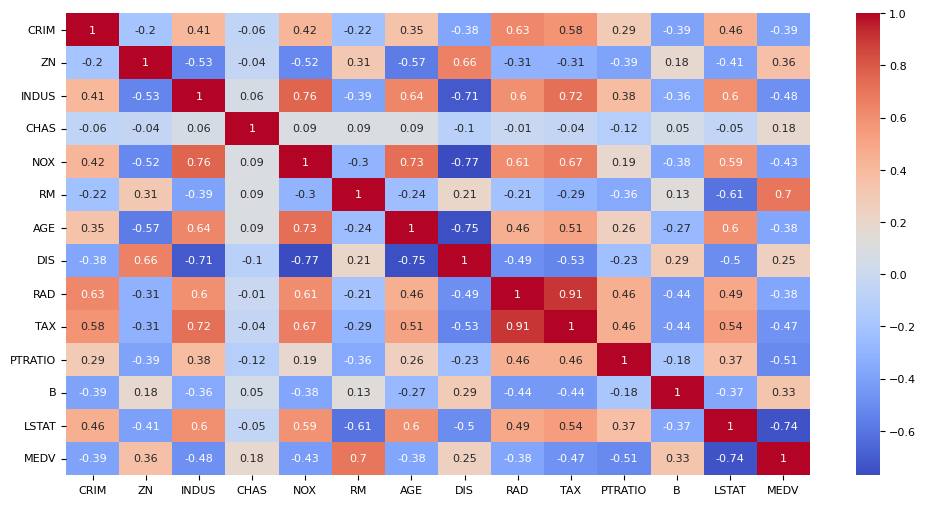

In [32]:
correlation_matrix = df.corr().round(2)
plt.figure(figsize=(12, 6))
sns.heatmap(data=correlation_matrix, annot=True, cmap="coolwarm")
plt.show()

### Calculating Multicollinearity

In [73]:
X = df.drop("MEDV", axis=1)
variables = X.values
variables.shape

(506, 13)

In [76]:
model = sm.OLS(y, sm.add_constant(X)).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                   MEDV   R-squared:                       0.741
Model:                            OLS   Adj. R-squared:                  0.734
Method:                 Least Squares   F-statistic:                     108.1
Date:                Mon, 15 Sep 2025   Prob (F-statistic):          6.72e-135
Time:                        13:25:40   Log-Likelihood:                -1498.8
No. Observations:                 506   AIC:                             3026.
Df Residuals:                     492   BIC:                             3085.
Df Model:                          13                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         36.4595      5.103      7.144      0.0

**Przykłady interpretacji:**

* RM (liczba pokoi):
    * coef = 3.8099 → każdy dodatkowy pokój zwiększa MEDV średnio o 3.81 tys. $
    * p-value ≈ 0 → współczynnik statystycznie istotny

* NOX (stężenie tlenków azotu):
    * coef = -17.77 → wzrost NOX o jednostkę zmniejsza MEDV o ~17,8 tys. $
    * p-value ≈ 0 → istotny

* AGE:
    * coef ≈ 0, 
    * p-value = 0.958 → współczynnik nieistotny


* Omnibus / Jarque-Bera – test normalności reszt. Tutaj p≈0 → reszty nie są normalne (Prob(Omnibus) = 0.000, Prob(JB) = 8.84e-171)
    * Hipoteza zerowa (H₀): reszty mają rozkład normalny.
    * Hipoteza alternatywna (H₁): reszty nie są normalne.
    * Jeśli p < 0.05 → odrzucamy H₀ → tutaj: „p≈0” - to oznacza, że prawdopodobieństwo zaobserwowania takiej statystyki (JB = 783) przy normalnych resztach jest praktycznie zerowe → reszty są zdecydowanie nienormalne.
* Skew / Kurtosis – asymetria i spłaszczenie rozkładu reszt.
* Durbin-Watson – test autokorelacji reszt. 1.078 → możliwa dodatnia autokorelacja.
* Cond. No. (Condition Number) – bardzo duże (15100) → wskazuje na silną kolinearność lub problemy numeryczne.


**Skew / Kurtosis – asymetria i spłaszczenie reszt**
* Skew (skośność): mierzy asymetrię rozkładu.
        * Skew > 0 → prawa ogon jest dłuższa (rozkład przesunięty w lewo).
        * Skew < 0 → lewa ogon jest dłuższa.

* Kurtosis (kurtoza): mierzy „wysokość” rozkładu (tzw. ogony).
        * Kurtoza = 3 → rozkład normalny.
        * Kurtoza > 3 → ciężkie ogony (większe ryzyko wartości odstających).

Tutaj: skew = 1.521 (dodatnia asymetria), kurtosis = 8.281 → reszty są silnie skośne i mają ciężkie ogony.


**Durbin-Watson – test autokorelacji reszt**
* Sprawdza, czy reszty są ze sobą niezależne.
* Wartość testu:
        * ~2 → brak autokorelacji
        * < 2 → dodatnia autokorelacja
        * 2 → ujemna autokorelacja

Tutaj: Durbin-Watson = 1.078 → możliwa dodatnia autokorelacja - błędy w kolejnych obserwacjach mogą być powiązane - typowe w danych czasowych lub przestrzennych.


**Condition Number (Cond. No.)**
* Mierzy numeryczną stabilność macierzy XᵀX.
* Bardzo duża wartość → problemy z kolinearnością między zmiennymi.
* Tutaj: 15100 → bardzo duża, więc:
    * Niektóre współczynniki β mogą być niestabilne (zmieniają się mocno przy małych zmianach danych).
    * Model może mieć problemy numeryczne przy obliczeniach.

**Podsumowanie praktyczne**
* Model wyjaśnia ~74% wariancji MEDV (R²).
* Kilka zmiennych jest nieistotnych statystycznie (np. AGE, INDUS).
* Duży condition number → należy sprawdzić VIF i rozważyć:
        * usunięcie lub połączenie zmiennych
        * Ridge/Lasso
        * PCA

---

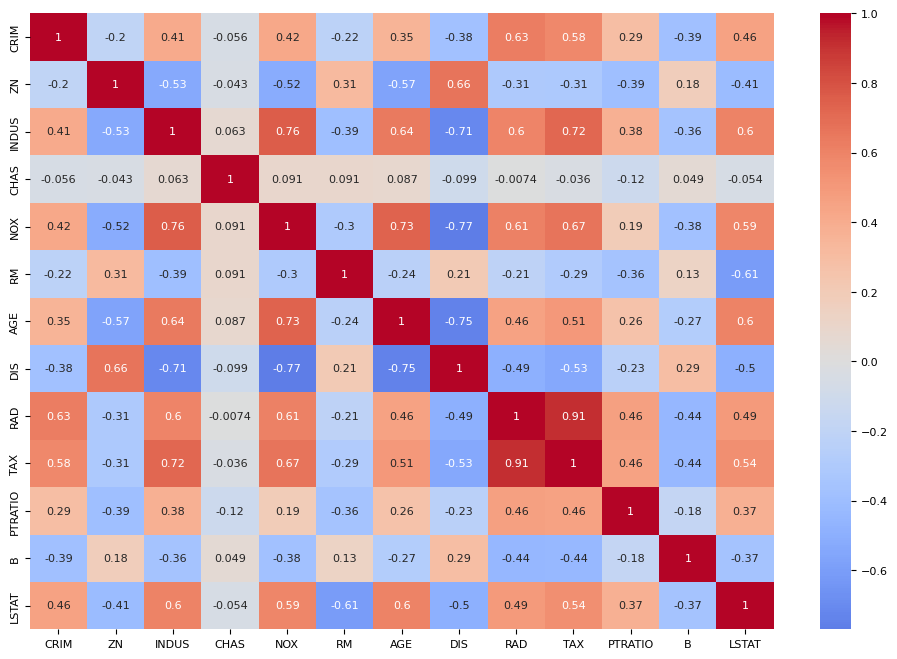

In [83]:
corr = X.corr()
plt.figure(figsize=(12, 8))
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0)
plt.show()

### Calculating Multicollinearity using VIF (Variance Infaltion Factor)


VIF measures how strongly an explanatory variable $X_j$ is linearly related to the other variables in the model.

**Formula:**

$$
VIF_j = \frac{1}{1 - R_j^2}
$$

where $R_j^2$ is the coefficient of determination from regressing variable $X_j$ on all the other predictors.

**Interpretation:**

- $VIF = 1$ → no correlation with other predictors.  
- $1 < VIF < 5$ → moderate correlation, usually acceptable.  
- $VIF > 5$ (sometimes the threshold is 10) → strong correlation, multicollinearity problem.

In [35]:
X = df.drop("MEDV", axis=1)
variables = X.values
variables.shape


(506, 13)

In [85]:
vif = pd.DataFrame()
vif["VIF"] = [variance_inflation_factor(variables, i) for i in range(variables.shape[1])]
vif["features"] = X.columns
vif.sort_values(by="VIF", ascending=False)

,VIF,features
10,85.029547,PTRATIO
5,77.948283,RM
4,73.894947,NOX
9,61.227274,TAX
6,21.386850,AGE
11,20.104943,B
8,15.167725,RAD
7,14.699652,DIS
2,14.485758,INDUS
12,11.102025,LSTAT


Many variables (NOX, RM, TAX, PTRATIO) are strongly correlated with other variables in the dataset.

A linear model using all these features may have unstable coefficients, making it difficult to interpret the effect of individual variables.

You can consider:
* **Removing the most collinear variables**
* **Combining correlated variables**
* **Using dimensionality reduction techniques (e.g., PCA)**
* **Usin Ridge (L2 - Lasso)** regularization to reduce the impact of multicollinearity.
* **Using tree-based algorithms (Random Forest, XGBoost)** which are insensitive to correlation.

#### Removing the most collinear variables

In [41]:
vif_rem = vif.copy()

threshold = 30
high_vif_features = vif_rem.loc[vif_rem["VIF"] > threshold, "features"]
high_vif_features

4         NOX
5          RM
9         TAX
10    PTRATIO
Name: features, dtype: object

In [42]:
vif_rem_reduced = vif_rem.loc[~vif_rem["features"].isin(high_vif_features)]
vif_rem_reduced

,VIF,features
0,2.100373,CRIM
1,2.844013,ZN
2,14.485758,INDUS
3,1.152952,CHAS
6,21.386850,AGE
7,14.699652,DIS
8,15.167725,RAD
11,20.104943,B
12,11.102025,LSTAT


#### Combining variables into indices (e.g., PCA)

In [53]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=5)
X_pca = pca.fit_transform(X_scaled)

pca_columns = [f"PC{i+1}" for i in range(X_pca.shape[1])]
X_pca_df = pd.DataFrame(X_pca, columns=pca_columns)

X_pca_df.head(3)

,PC1,PC2,PC3,PC4,PC5
0,-2.098297,0.773113,0.342943,-0.891774,-0.423070
1,-1.457252,0.591985,-0.695199,-0.487459,0.195876
2,-2.074598,0.599639,0.167122,-0.739204,0.934534


In [54]:
pca.explained_variance_ratio_

array([0.47129606, 0.11025193, 0.0955859 , 0.06596732, 0.06421661])

In [55]:
components_df = pd.DataFrame(
    pca.components_, columns=X.columns, index=[f"PC{i+1}" for i in range(5)]
)
components_df

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT
PC1,0.250951,-0.256315,0.346672,0.005042,0.342852,-0.189243,0.313671,-0.321544,0.319793,0.338469,0.204942,-0.202973,0.309760
PC2,-0.315252,-0.323313,0.112493,0.454829,0.219116,0.149332,0.311978,-0.349070,-0.271521,-0.239454,-0.305897,0.238559,-0.074322
PC3,0.246566,0.295858,-0.015946,0.289781,0.120964,0.593961,-0.017675,-0.049736,0.287255,0.220744,-0.323446,-0.300146,-0.267000
PC4,0.061771,0.128712,0.017146,0.815941,-0.128226,-0.280592,-0.175206,0.215436,0.132350,0.103335,0.282622,0.168498,0.069414
PC5,-0.082157,-0.320617,0.007811,-0.086531,-0.136854,0.423447,-0.016691,-0.098592,0.204132,0.130461,0.584002,0.345607,-0.394561


#### L2 Regularization (Lasso)

In [70]:
from sklearn.linear_model import Lasso
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

In [71]:
# Lasso Regression

lasso = Lasso(alpha=0.1)
lasso.fit(X_train, y_train)
y_pred_lasso = lasso.predict(X_test)
print("Lasso MSE:", mean_squared_error(y_test, y_pred_lasso))

Lasso MSE: 25.68451830859077


In [67]:
print("Lasso coefficients:", pd.Series(lasso.coef_, index=X.columns))

Lasso coefficients: CRIM      -0.700552
ZN         0.256615
INDUS     -0.000000
CHAS       0.688573
NOX       -1.557390
RM         3.243104
AGE       -0.000000
DIS       -2.261254
RAD        0.667039
TAX       -0.338474
PTRATIO   -1.845910
B          1.028481
LSTAT     -3.621010
dtype: float64


## What assumptions are made in _linear regression modeling_?

**Linear regression** makes several key assumptions about the nature of the relationship between the independent and dependent variables for the model to be valid.

### Assumptions of Linear Regression

1. **Linear Relationship**: There is a linear relationship between the independent variables $X$ and the dependent variable $Y$.
2. **No or Little Multicollinearity**: The features should be linearly independent. Having high multicolliearity, i.e., linear relationship between the features, can skew the interpretation of model coefficients.
3. **Multivariate Normality**: The error term, $\varepsilon$, is normally distributed.
4. **Homoscedasticity**: The variance of the residual ($y-\hat{y}$) is the same for any value of independent variable $X$.
5. **Independence of Errors**: The observations are independent of each other. This is commonly checked by ensuring there's no pattern in the way the data was collected over time.

7. **No Auto-correlation**: When dealing with time series data, one must ensure that the current observation is not correlated with any of the previous observations.

8. **Feature Normalization**: This is not exactly an assumption, but is generally recommended for better convergence during the optimization process.

**1. Liniowość zależności**

👉 Zależność między zmiennymi niezależnymi (X) a zmienną zależną (y) jest liniowa.

* W praktyce: jeżeli np. liczba pokoi (RM) rośnie, to MEDV (cena domu) zmienia się liniowo.
* Tutaj: RM ma coef ≈ 3.8 i p≈0.000 → bardzo silna i istotna zależność liniowa.
* Jeśli związek byłby nieliniowy, reszty pokazałyby systematyczne wzorce na wykresie.

**2. Brak (silnej) multikolinearności**

👉 Predyktory nie powinny być zbyt mocno skorelowane ze sobą.

* Dlaczego? Bo wtedy trudno rozróżnić, która zmienna faktycznie tłumaczy y. Współczynniki β stają się niestabilne.

Tutaj:

* VIF dla TAX = 61.2, NOX = 73.9, PTRATIO = 85.0 → poważna multikolinearność.
* Macierz korelacji (X.corr()): TAX–RAD = 0.91, NOX–INDUS = 0.76 → zmienne są mocno powiązane.
* model.summary(): Condition No. = 1.51e+04 → potwierdza problem z kolinearnością.

✅ Wniosek: modele liniowe z tymi wszystkimi zmiennymi będą trudne do interpretacji → trzeba np. usunąć zmienne, użyć Ridge/Lasso lub PCA.

**3. Normalność reszt**

👉 Reszty powinny mieć rozkład normalny.

Po co? Żeby testy istotności (t-test, F-test) były poprawne.

Tutaj w summary():
* Jarque-Bera (JB) = 783.126, p≈0 → reszty nie są normalne.
* Skew = 1.52, Kurtosis = 8.28 → reszty są skośne i mają ciężkie ogony.
* Interpretacja: model daje dobre R², ale testy p-value mogą być zaniżone lub zawyżone

**4. Homoskedastyczność reszt**

👉 Rozrzut reszt powinien być stały dla wszystkich wartości X.

* Jeśli wariancja rośnie (heteroskedastyczność), to standardowe błędy są źle policzone, a p-value niepewne.
* Jak sprawdzić? → wykres reszt vs przewidywania (plt.scatter(y_pred, residuals)).
* Heteroskedastyczność często idzie w parze z problemem nienormalności reszt (co już widać w przykładzie).
  * Gdy wariancja błędów rośnie dla dużych wartości X, to nasze wzory zakładające stałą wariancję są błędne.
  * Efekt:
    * Standard errors mogą być zaniżone → p-value za małe (myślisz, że zmienna jest istotna, a wcale nie jest).
    * Mogą być też zawyżone → p-value za duże (odrzucasz zmienną, mimo że ma wpływ).
    * Jeśli podejrzewasz heteroskedastyczność → używasz robust standard errors (np. `HC0`, `HC3` w `statsmodels`).

In [87]:

# Zwykły OLS (klasyczne założenie homoskedastyczności)
model_ols = sm.OLS(y, sm.add_constant(X)).fit()
print("=== Klasyczne OLS ===")
print(model_ols.summary())

# OLS z poprawką na heteroskedastyczność (robust standard errors)
model_robust = model_ols.get_robustcov_results(cov_type="HC3")  # można też "HC0", "HC1"
print("\n=== OLS z robust SE (HC3) ===")
print(model_robust.summary())

=== Klasyczne OLS ===
                            OLS Regression Results                            
Dep. Variable:                   MEDV   R-squared:                       0.741
Model:                            OLS   Adj. R-squared:                  0.734
Method:                 Least Squares   F-statistic:                     108.1
Date:                Mon, 15 Sep 2025   Prob (F-statistic):          6.72e-135
Time:                        15:10:05   Log-Likelihood:                -1498.8
No. Observations:                 506   AIC:                             3026.
Df Residuals:                     492   BIC:                             3085.
Df Model:                          13                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         36.4595      5.1

* Współczynniki (coef) → będą identyczne w obu modelach, bo OLS nadal daje nieobciążone estymatory.
* Standard errors (std err) i p-value → mogą być różne, szczególnie dla zmiennych, gdzie reszty mają zmienną wariancję.
* Jeśli przy zwykłym OLS p < 0.05, a w wersji robust nagle p > 0.05 → znaczy, że klasyczny model przeszacował istotność zmiennej (bo SE były zaniżone).
* Tutaj:
  * CHAS – duża różnica: w klasycznym OLS p=0.002 (silny efekt), w robust p=0.046 (ledwo istotne przy α=0.05).
  * 👉 To oznacza, że heteroskedastyczność zawyżała istotność CHAS w zwykłym OLS.

**5. Niezależność reszt**

👉 Reszty nie powinny być ze sobą skorelowane.

Po co? Bo wtedy błędy nie są losowe, tylko „ciągną się” w czasie lub przestrzeni.

Tutaj w summary():
  * Durbin-Watson = 1.078 → wskazuje na dodatnią autokorelację reszt.
  * To problem szczególnie w danych czasowych lub przestrzennych (a Boston Housing ma cechy przestrzenne → lokalizacja, dostępność do dróg, NOX, TAX itd.).

**6. Brak dużych wartości odstających i wpływowych**

👉 Pojedyncze obserwacje nie powinny dominować nad modelem.

* Jak sprawdzić? → wykres dźwigni (leverage) i wartości Cook’s distance.
* W Boston Housing występują wartości odstające w MEDV (np. kilka domów z ekstremalnie wysoką lub niską ceną), co może wpływać na normalność reszt i współczynniki.